# Разведочный анализ данных (EDA) в Dask для датасета Expresso Churn Prediction

### 1. Настройка Dask Client и чтение данных
Сначала подключаем Client для распределённых вычислений. Blocksize=128MB — оптимально для большого CSV, чтобы разбить на partitions.

In [19]:
import dask.dataframe as dd
from dask.distributed import Client
import coloredlogs, logging
import os
import matplotlib.pyplot as plt
import seaborn as sns


# Настройка логов (coloredlogs для readability в портфолио)
logger = logging.getLogger(__name__)
coloredlogs.install(level='INFO', logger=logger, fmt='%(asctime)s [%(levelname)s] %(message)s',
                    level_styles={'info': {'color': 'green'}, 'error': {'color': 'red', 'bold': True}})
logger.info("Starting Dask Client for distributed EDA")

# Client для локального кластера (или Kubernetes: Client(cluster='tcp://scheduler:8786'))
client = Client(n_workers=4, threads_per_worker=2, memory_limit='4GB')  # Масштабируй до 12 workers в K8s
logger.info(f"Dask dashboard: {client.dashboard_link}")

# Чтение данных (lazy, не загружает в память)
train_path = 'C:/vs_code_projects/distributed-churn-prediction/data/source/Train.csv'  # Или s3://bucket/Train.csv для cloud
ddf = dd.read_csv(train_path, blocksize='128MB', assume_missing=True)  # assume_missing для NaN в floats
logger.info(f"Partitions: {ddf.npartitions}")  # ~10-20 для 500MB файла

2026-03-03 22:51:35 [INFO] Starting Dask Client for distributed EDA
c:\ProgramData\miniconda\envs\dist-churn-pred-env\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 64766 instead
  warnings.warn(
2026-03-03 22:51:39 [INFO] Dask dashboard: http://127.0.0.1:64766/status
2026-03-03 22:51:39 [INFO] Partitions: 2


### 2. Базовая информация (shape, dtypes, head)
Dask не загружает данные сразу — .head() берёт sample с первых partitions.

In [3]:
# Кол-во строк и колонок (distributed len)
num_rows = len(ddf)
num_cols = len(ddf.columns)
logger.info(f"Dataset shape: {num_rows} rows, {num_cols} columns")

# Типы данных
dtypes = ddf.dtypes
logger.info(f"Data types:\n{dtypes}")

# Sample первых 5 строк (compute only head)
sample = ddf.head(5)
print("\nSample rows:\n", sample)

2026-03-03 22:32:45 [INFO] Dataset shape: 2154048 rows, 19 columns
2026-03-03 22:32:45 [INFO] Data types:
user_id            string
REGION             string
TENURE             string
MONTANT           float64
FREQUENCE_RECH    float64
REVENUE           float64
ARPU_SEGMENT      float64
FREQUENCE         float64
DATA_VOLUME       float64
ON_NET            float64
ORANGE            float64
TIGO              float64
ZONE1             float64
ZONE2             float64
MRG                string
REGULARITY        float64
TOP_PACK           string
FREQ_TOP_PACK     float64
CHURN             float64
dtype: object



Sample rows:
                                     user_id  REGION         TENURE  MONTANT  \
0  00000bfd7d50f01092811bc0c8d7b0d6fe7c3596  FATICK   K > 24 month   4250.0   
1  00000cb4a5d760de88fecb38e2f71b7bec52e834    <NA>  I 18-21 month      NaN   
2  00001654a9d9f96303d9969d0a4a851714a4bb57    <NA>   K > 24 month   3600.0   
3  00001dd6fa45f7ba044bd5d84937be464ce78ac2   DAKAR   K > 24 month  13500.0   
4  000028d9e13a595abe061f9b58f3d76ab907850f   DAKAR   K > 24 month   1000.0   

   FREQUENCE_RECH  REVENUE  ARPU_SEGMENT  FREQUENCE  DATA_VOLUME  ON_NET  \
0            15.0   4251.0        1417.0       17.0          4.0   388.0   
1             NaN      NaN           NaN        NaN          NaN     NaN   
2             2.0   1020.0         340.0        2.0          NaN    90.0   
3            15.0  13502.0        4501.0       18.0      43804.0    41.0   
4             1.0    985.0         328.0        1.0          NaN    39.0   

   ORANGE  TIGO  ZONE1  ZONE2 MRG  REGULARITY        

### 3. Описательная статистика (describe)
Для числовых колонок — mean, min, max, etc. Dask распределяет расчёты по workers.

In [11]:
# Самый стабильный способ в новых версиях Dask
numerical_ddf = ddf.select_dtypes(include="number")   # ← "number" вместо списка типов!
# Описательная статистика — распределённо
desc = numerical_ddf.describe().compute()

logger.info(f"Numerical columns found: {len(numerical_ddf.columns)}")
print(desc.round(2))   # красиво округляем для отчёта

# Дополнительно: список колонок для портфолио
num_cols_list = numerical_ddf.columns.tolist()
logger.info(f"Numerical columns: {num_cols_list}")


# Для categorical — отдельно value_counts (пример для REGION)
region_counts = ddf['REGION'].value_counts().compute()
logger.info("REGION value counts:\n")
print(region_counts)

2026-03-03 22:41:28 [INFO] Numerical columns found: 14
2026-03-03 22:41:28 [INFO] Numerical columns: ['MONTANT', 'FREQUENCE_RECH', 'REVENUE', 'ARPU_SEGMENT', 'FREQUENCE', 'DATA_VOLUME', 'ON_NET', 'ORANGE', 'TIGO', 'ZONE1', 'ZONE2', 'REGULARITY', 'FREQ_TOP_PACK', 'CHURN']


          MONTANT  FREQUENCE_RECH     REVENUE  ARPU_SEGMENT   FREQUENCE  \
count  1397309.00      1397309.00  1428000.00    1428000.00  1428000.00   
mean      5532.12           11.53     5510.81       1836.94       13.98   
std       7111.34           13.27     7187.11       2395.70       14.69   
min         10.00            1.00        1.00          0.00        1.00   
25%       1000.00            2.00     1000.00        333.00        3.00   
50%       3000.00            7.00     3000.00       1000.00        9.00   
75%       7400.00           16.00     7394.00       2465.00       20.00   
max     470000.00          133.00   532177.00     177392.00       91.00   

       DATA_VOLUME      ON_NET      ORANGE       TIGO      ZONE1      ZONE2  \
count   1093615.00  1367373.00  1258800.00  864032.00  169721.00  136824.00   
mean       3366.45      277.69       95.42      23.11       8.17       7.55   
std       13304.46      872.69      204.99      63.58      41.17      33.49   
min     

2026-03-03 22:41:34 [INFO] REGION value counts:



REGION
DIOURBEL        66911
KOLDA           38743
LOUGA           99053
SAINT-LOUIS    119886
SEDHIOU          3119
TAMBACOUNDA     55074
THIES          180052
ZIGUINCHOR      21945
DAKAR          513271
FATICK          35643
KAFFRINE        43963
KAOLACK         96986
KEDOUGOU         1020
MATAM           29083
Name: count, dtype: int64[pyarrow]


### 4. Анализ пропусков (missing values)
Ключевой для этого датасета (много NaN). Распределённый sum.

2026-03-03 22:54:44 [INFO] === Анализ пропусков в Dask (distributed) ===
2026-03-03 22:54:49 [INFO] Missing values % (sorted):

2026-03-03 22:54:49 [INFO] ✅ Сохранено: reports/missing_values.csv


ZONE2             93.65
ZONE1             92.12
TIGO              59.89
DATA_VOLUME       49.23
TOP_PACK          41.90
FREQ_TOP_PACK     41.90
ORANGE            41.56
REGION            39.43
ON_NET            36.52
MONTANT           35.13
FREQUENCE_RECH    35.13
FREQUENCE         33.71
ARPU_SEGMENT      33.71
REVENUE           33.71
user_id            0.00
TENURE             0.00
MRG                0.00
REGULARITY         0.00
CHURN              0.00
dtype: float64


2026-03-03 22:54:50 [INFO] ✅ График reports/missing_values.png


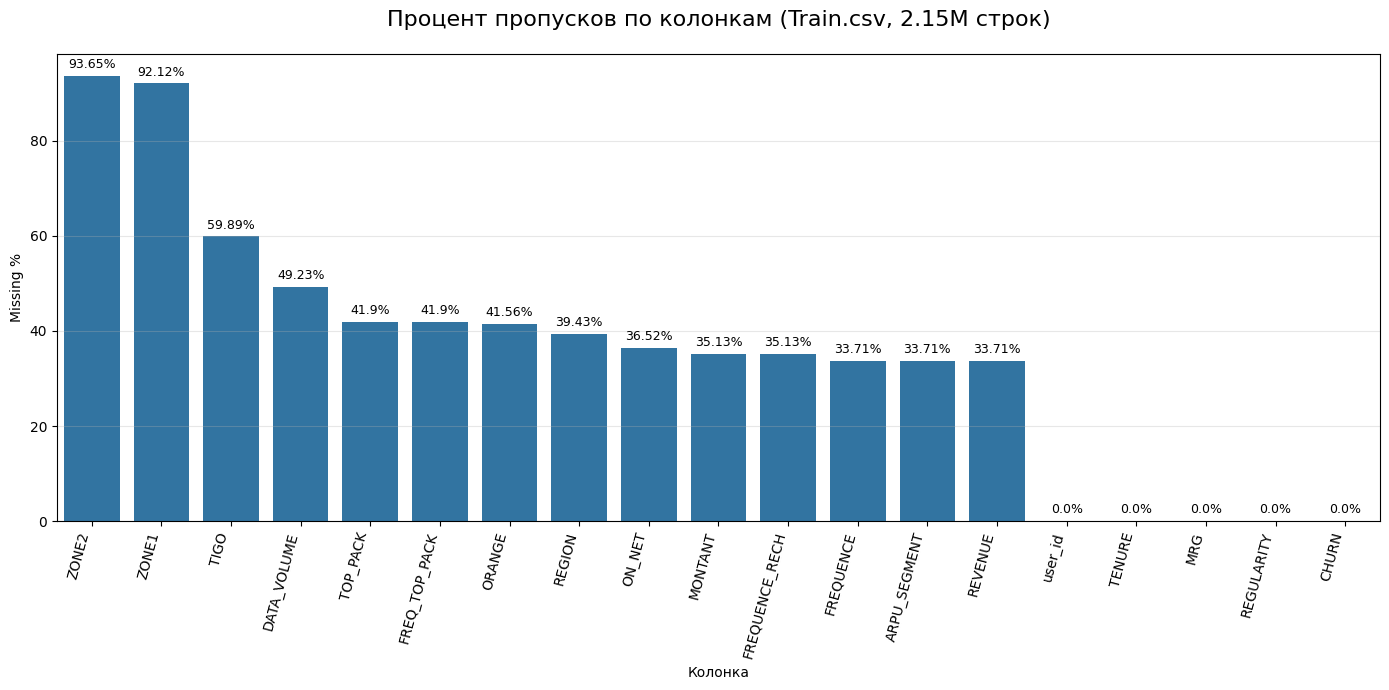

In [ ]:
# ====================== ИСПРАВЛЕННЫЙ БЛОК ПРОПУСКОВ ======================
logger.info("=== Анализ пропусков в Dask (distributed) ===")

# Один compute — максимальная эффективность
missing_pct = (
    ddf.isnull()
    .mean()           # лучше, чем .sum() / len()
    .mul(100)         # *100
    .compute()        # только здесь
    .sort_values(ascending=False)
    .round(2)
)

logger.info("Missing values % (sorted):\n")
print(missing_pct)

# Сохраняем в CSV для отчёта портфолио
REPORTS_DIR = "reports/"
if not os.path.exists(REPORTS_DIR):
    logger.info(f'Создана папка {REPORTS_DIR}')
    os.makedirs(REPORTS_DIR)

missing_pct.to_frame(name="missing_percent").to_csv(REPORTS_DIR + "missing_values.csv")
logger.info(f"✅ Сохранено: {REPORTS_DIR}missing_values.csv")

# ====================== ВИЗУАЛИЗАЦИЯ ======================

plt.figure(figsize=(14, 7))
ax = sns.barplot(
    x=missing_pct.index, 
    y=missing_pct.values,
)

plt.xticks(rotation=75, ha='right')
plt.title('Процент пропусков по колонкам (Train.csv, 2.15M строк)', fontsize=16, pad=20)
plt.ylabel('Missing %')
plt.xlabel('Колонка')
plt.grid(axis='y', alpha=0.3)

# Добавляем подписи значений сверху столбцов (очень полезно в отчёте)
for i, v in enumerate(missing_pct.values):
    ax.text(i, v + 1, f"{v}%", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(REPORTS_DIR + 'missing_values.png', dpi=300, bbox_inches='tight')
logger.info(f"✅ График {REPORTS_DIR}missing_values.png")
plt.show()
# =====================================================================

### 6. Распределения (histograms, boxplots)
Для визуализации — compute subsets или approx.

2026-03-03 22:57:14 [INFO] === Распределения и boxplots (sample + seaborn) ===
2026-03-03 22:57:22 [INFO] ✅ Гистограмма сохранена: reports/hist_regularity.png


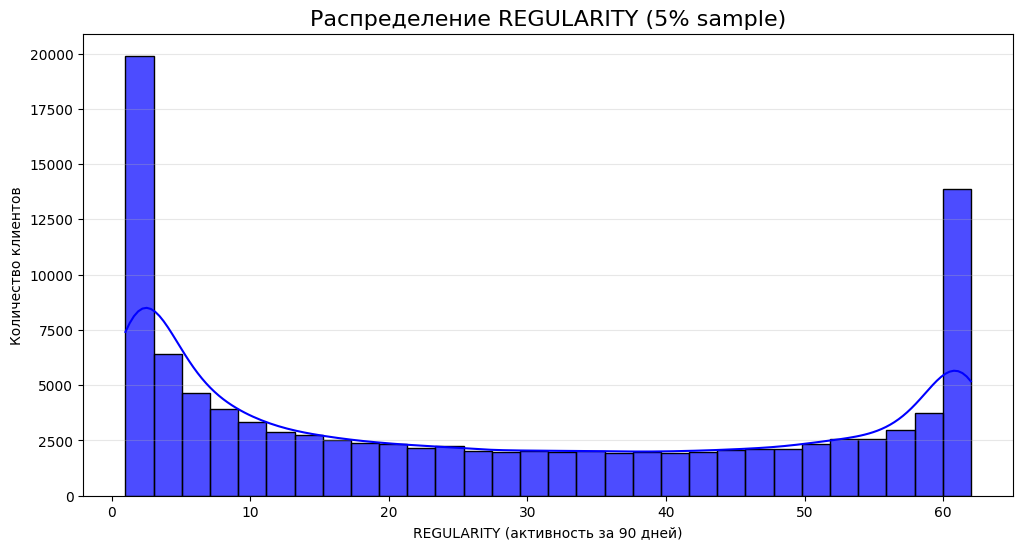

2026-03-03 22:57:28 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\кс\AppData\Local\Temp\ipykernel_8892\1906066215.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CHURN', y='REGULARITY', data=sample_df, palette="Set2")
2026-03-03 22:57:29 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-03 22:57:29 [INFO] ✅ Boxplot сохранён: reports/boxplot_churn_regularity.png


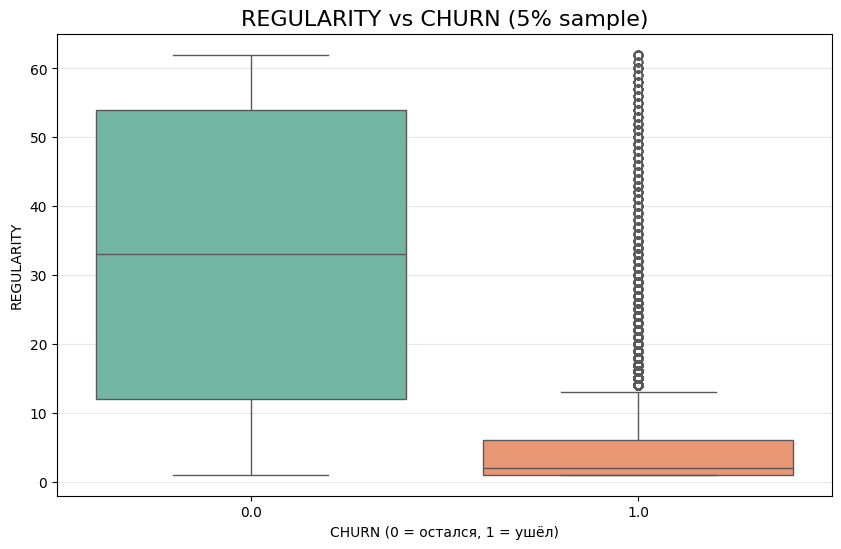

2026-03-03 22:57:36 [INFO] ✅ Обзор распределений сохранён


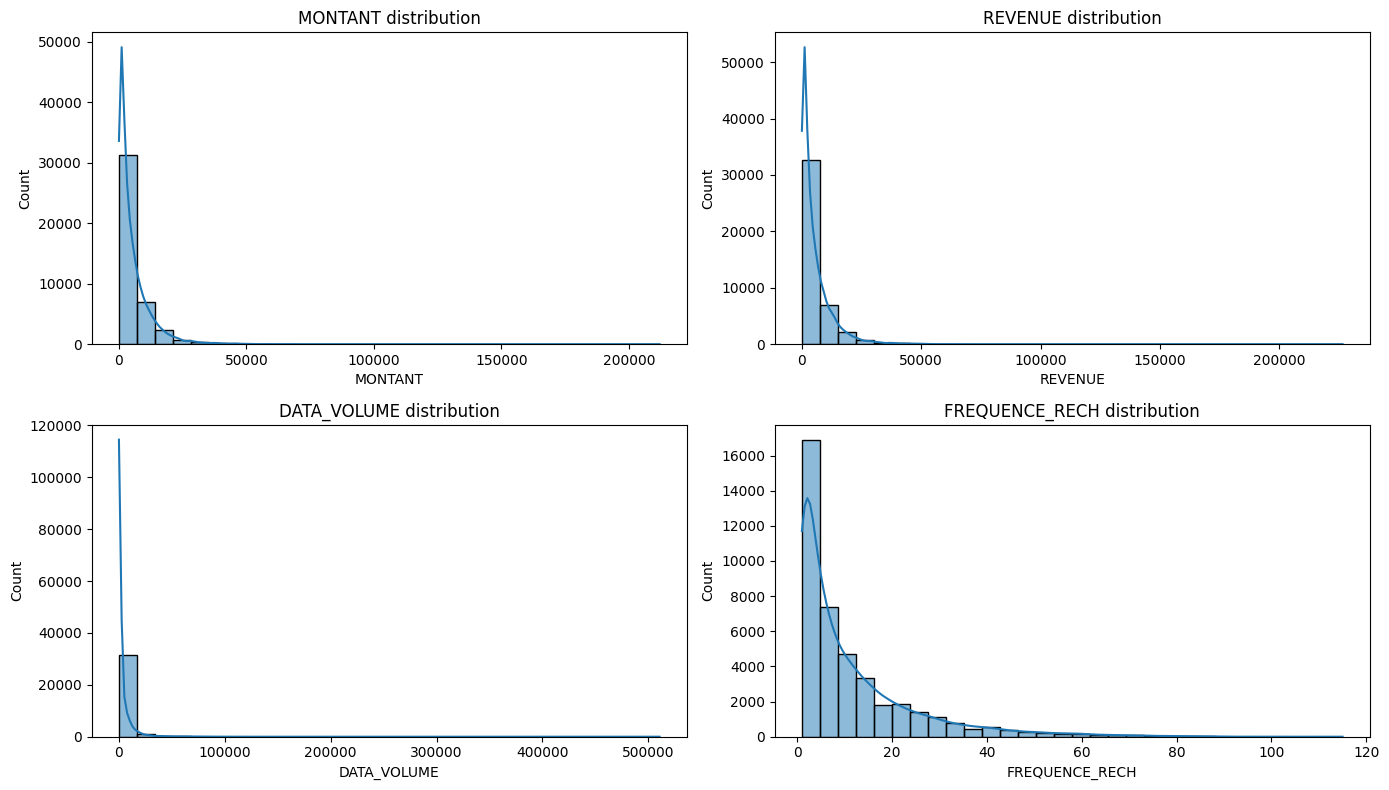

In [24]:
# ====================== ИСПРАВЛЕННЫЙ БЛОК ВИЗУАЛИЗАЦИЙ ======================
logger.info("=== Распределения и boxplots (sample + seaborn) ===")

# 1. Гистограмма REGULARITY (ключевой признак!)
reg_sample = ddf['REGULARITY'].sample(frac=0.05, random_state=42).compute()  # 5% — ~107k строк, быстро

plt.figure(figsize=(12, 6))
sns.histplot(reg_sample, bins=30, kde=True, color='blue', alpha=0.7)
plt.title('Распределение REGULARITY (5% sample)', fontsize=16)
plt.xlabel('REGULARITY (активность за 90 дней)')
plt.ylabel('Количество клиентов')
plt.grid(axis='y', alpha=0.3)
plt.savefig('reports/hist_regularity.png', dpi=300, bbox_inches='tight')
logger.info("✅ Гистограмма сохранена: reports/hist_regularity.png")
plt.show()

# 2. Boxplot: REGULARITY в разрезе CHURN (самый важный график для отчёта!)
sample_df = ddf.sample(frac=0.05, random_state=42)[['REGULARITY', 'CHURN']].compute()

plt.figure(figsize=(10, 6))
sns.boxplot(x='CHURN', y='REGULARITY', data=sample_df, palette="Set2")
plt.title('REGULARITY vs CHURN (5% sample)', fontsize=16)
plt.xlabel('CHURN (0 = остался, 1 = ушёл)')
plt.ylabel('REGULARITY')
plt.grid(axis='y', alpha=0.3)
plt.savefig('reports/boxplot_churn_regularity.png', dpi=300, bbox_inches='tight')
logger.info("✅ Boxplot сохранён: reports/boxplot_churn_regularity.png")
plt.show()

# 3. Быстрый взгляд на несколько числовых признаков (для портфолио)
num_cols = ['MONTANT', 'REVENUE', 'DATA_VOLUME', 'FREQUENCE_RECH']
sample_multi = ddf.sample(frac=0.03, random_state=42)[num_cols].compute()

plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(sample_multi[col].dropna(), bins=30, kde=True)
    plt.title(f'{col} distribution')
plt.tight_layout()
plt.savefig('reports/distributions_overview.png', dpi=300)
logger.info("✅ Обзор распределений сохранён")
plt.show()
# =====================================================================